# Assignment: week 5

The objectives of this assignment are:

1. to learn about residual connections and layer normalization, and their implementation
2. to assemble a model using these components (simplified Transformer encoder block)


<a id="encoder-diagram"></a>

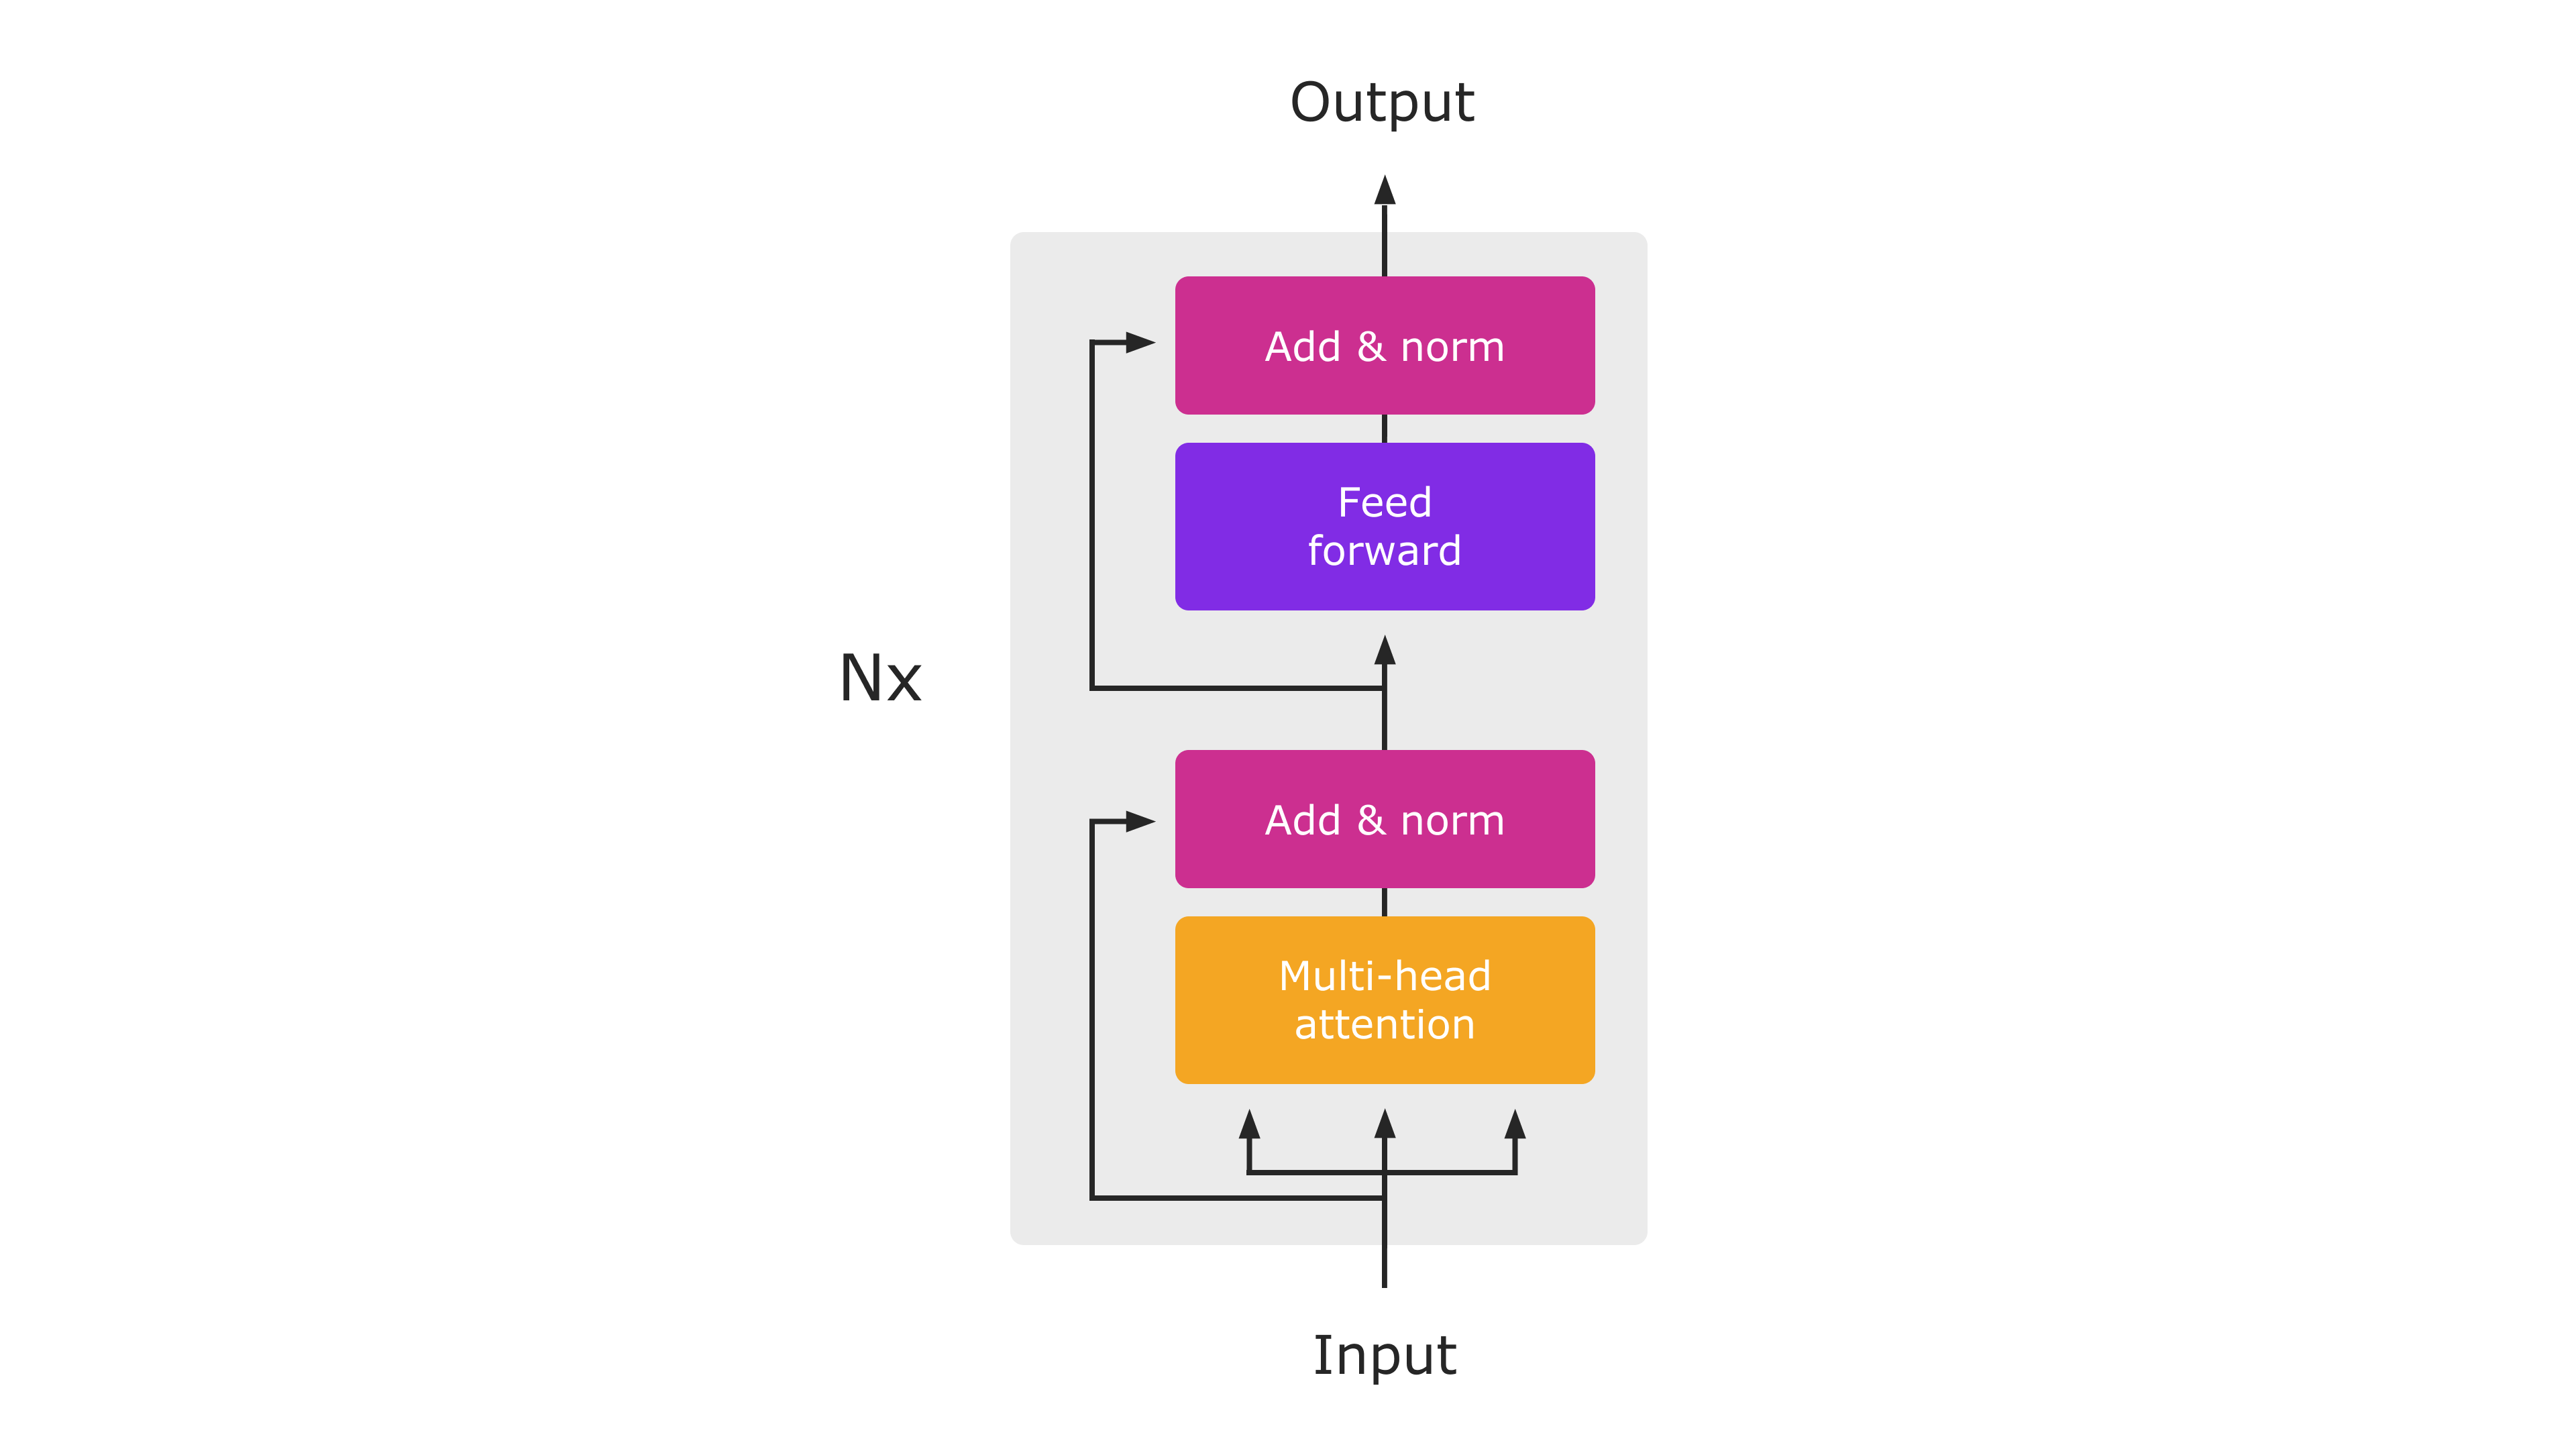

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import Input, Model
from keras.layers import Dense, Layer, Embedding, GlobalAveragePooling1D, Dropout, MultiHeadAttention, LayerNormalization
from keras.callbacks import EarlyStopping
from keras.models import Model
from keras.datasets import imdb

## Initializations and preparation

In [16]:
max_features = 10000
max_seq = 250

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = keras.utils.pad_sequences(x_train, maxlen=max_seq, padding='post')
x_test = keras.utils.pad_sequences(x_test, maxlen=max_seq, padding='post')

c:\Users\tonyk\anaconda3\envs\keras\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [17]:
wrd_to_idx = imdb.get_word_index()
idx_to_wrd = dict((value, key) for (key, value) in wrd_to_idx.items())

In [18]:
example_review = " ".join(idx_to_wrd.get(i-3, "?") for i in x_train[0])
print(example_review)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [19]:
class TokenAndPositionEmb(Layer):
    def __init__(self, seq_len, vocab_size, emb_dim):
        super(TokenAndPositionEmb, self).__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=emb_dim)
        self.pos_emb = Embedding(input_dim=seq_len, output_dim=emb_dim)
        
    def call(self, x_input):
        seq_len = keras.ops.shape(x_input)[-1]
        positions = keras.ops.arange(start=0, stop=seq_len, step=1)
        positions = self.pos_emb(positions)
        x_input = self.token_emb(x_input)
        return x_input + positions

## Transformer encoder block

This part focuses on building the encoder block [(see here)](#encoder-diagram) with keras functional API.

### Multi-head attention block

First, we build the multi-head attention block by
1. Assigning hyperparameters. (embedding dimension / number of attention heads / key dimension)
2. Initializing inputs.
3. Combining tokens and their positions in sequence and making that the attention blocks residual connection.
4. Creating the multi-headed attention output with the previously assigned hyperparameters.
5. Adding the residual connection and the attention output together and normalizing them.

The last "Add + Normalize" layer is saved as the feedforward blocks residual connection, hence `residual_ff`.

In [20]:
embedding_dim = 32
num_heads = 2
key_dim = embedding_dim // num_heads


inputs = Input(shape=(max_seq,))
residual_att = TokenAndPositionEmb(max_seq, max_features, embedding_dim)(inputs)
attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(residual_att, residual_att)
residual_ff = LayerNormalization()(residual_att + attention_output)

### Feedforward block

Then, we build the feedforward block by
1. Creating a fully connected feedforward network using two `Dense` layers.
    - First layer has a unit size determined by the hyperparameters: ``embedding_dim`` and `multiplier`. It also uses ReLU as its activation function.
    - Second layer uses the embedding dimension itself as the unit size without any activation functions.
2. Adding the attention block’s residual connection to the feedforward network’s output and normalizing that sum.
3. Applying global average pooling to collapse the sequence into a fixed-size vector.
4. Applying dropout to reduce overfitting.

Lastly, we create an output layer suited for binary classification using sigmoid.

In [21]:
multiplier = 4
dropout = 0.5

ff = Dense(embedding_dim * multiplier, activation='relu')(residual_ff)
ff = Dense(embedding_dim)(ff)
x = LayerNormalization()(ff + residual_ff)
x = GlobalAveragePooling1D()(x)
x = Dropout(dropout)(x)
outputs = Dense(1, activation='sigmoid')(x)

Next, we create the model with the transformers inputs and outputs. We then compile it with the following parameters:
- ``Adam()`` as its optimizer
- `binary_crossentropy` as its loss function
- `accuracy` as its evaluation metric

Lastly, we show the summary of the models parameters and shape.

In [22]:
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 250, 32)   │    328,000 │ input_layer_1[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 250, 32)   │      4,224 │ token_and_positi… │
│ (MultiHeadAttentio… │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 250, 32)   │          0 │ token_and_positi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 250, 128)  │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 250, 32)   │      4,128 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 250, 32)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 250, 32)   │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 340,737 (1.30 MB)

 Trainable params: 340,737 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

## Training

Next, we train the model with 10 epochs and a simple EarlyStopping callback that monitors loss.

In [23]:
callbacks = [
    EarlyStopping('loss', patience=3)
]
model.fit(x_train, y_train, epochs=10, batch_size=32, callbacks=callbacks)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.7997 - loss: 0.4172
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9159 - loss: 0.2219
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9390 - loss: 0.1685
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.9539 - loss: 0.1320
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9651 - loss: 0.1050
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9747 - loss: 0.0834
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9789 - loss: 0.0696
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9810 - loss: 0.0636
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9853 - loss: 0.0512
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.9887 - loss: 0.0419


In [29]:
print(f'Test accuracy = {model.evaluate(x_test, y_test)[1]:.4f}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8382 - loss: 0.7383
Test accuracy = 0.8382


In [ ]:
# AI generated because the one in the course material didn't work for me
class MultiHeadWithScores(keras.layers.Layer):
    def __init__(self, attn_layer, **kwargs):
        super().__init__(**kwargs)
        self.attn = attn_layer
    def call(self, x):
        return self.attn(x, x, return_attention_scores=True)

inp = keras.Input(shape=model.input_shape[1:])
emb = model.layers[1](inp)
att_out, att_scores = MultiHeadWithScores(model.layers[2])(emb)

score_model = keras.Model(inputs=inp, outputs=[att_out, att_scores])

sample_input = x_train[:1]
_, attention_scores_all = score_model.predict(sample_input)

head_index = 1
attention_scores = attention_scores_all[0][head_index]
print(f"Attention scores, full shape: {attention_scores_all.shape}")
print(f"Attention scores, one head: {attention_scores.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Attention scores, full shape: (1, 2, 250, 250)
Attention scores, one head: (250, 250)


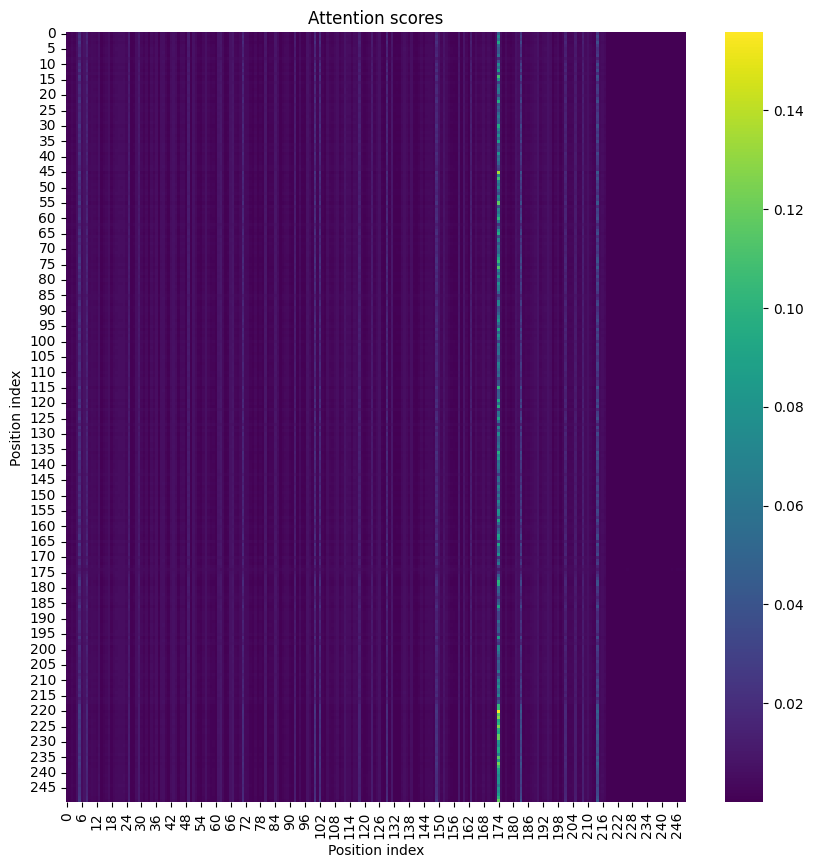

In [31]:
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.heatmap(attention_scores, cmap='viridis')
plt.title('Attention scores')
plt.xlabel('Position index')
plt.ylabel('Position index')
plt.show()

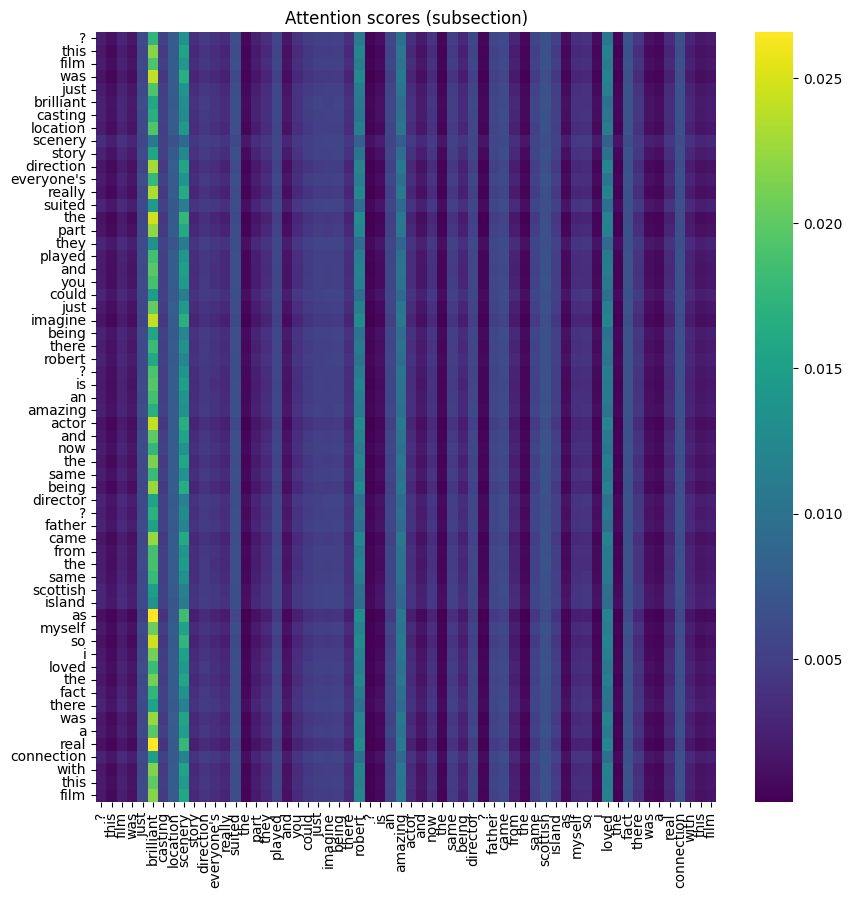

In [32]:
sub_length = 60  # Adjust the length of the subsection as needed
sub_scores = attention_scores[:sub_length, :sub_length]

# Plot the attention scores for the subsection
plt.figure(figsize=(10, 10))
sns.heatmap(sub_scores, 
            cmap='viridis',
            xticklabels=[idx_to_wrd.get(i-3, '?') for i in sample_input[0][:sub_length]],
            yticklabels=[idx_to_wrd.get(i-3, '?') for i in sample_input[0][:sub_length]])
plt.title('Attention scores (subsection)')
plt.show()

## Summary

The main objective of implementing a simple encoder block was achieved by combining multi-head attention and feedforward transformations with residual connections and normalization. The models accuracy was tested with good results, but the goal was a functioning encoder architecture itself and not so the metrics, which was achieved when we look at the figures.